#Project 6: Dog vs. Cat Image Classification


Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


The goal of this project is to build a **Convolutional Neural Network (CNN)** capable of classifying images as either dogs or cats. **Deep learning models** are particularly effective for image recognition because they automatically learn important visual features from raw pixel data. This project demonstrates the complete deep learning workflow, including loading image data, preprocessing, building a CNN, training the model, evaluating its performance, and using it to **classify** a new unseen image.



## Data Collection


In [1]:
import tensorflow.keras as keras
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

#Added
from tensorflow.keras.preprocessing import image


Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [2]:
#Load images
images_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'
images_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
#Load image pickle
image_array = pd.read_pickle(images_url)
type(image_array)

numpy.ndarray

In [4]:
#Load target labels
target_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'
target_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [5]:
#Load target pickle
target = pd.read_pickle(target_url)
target = np.array(target)

print(type(target))

<class 'numpy.ndarray'>


In [6]:
#Load test image URL
image_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'

In [7]:
#First pass using 500 images
image_array = image_array[:500]
target = target[:500]

## Data Cleaning


Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [8]:
#Scale pixel values
image_array = image_array / 255.0

## Exploratory Data Analysis



Look at the shape of X and y. Ensure that X is 4 dimensional.





In [9]:
#Check shapes
print(image_array.shape)
print(target.shape)

(500, 100, 100, 1)
(500,)


Plot a few ( >5 ) of the images in X using `plt.imshow()`.



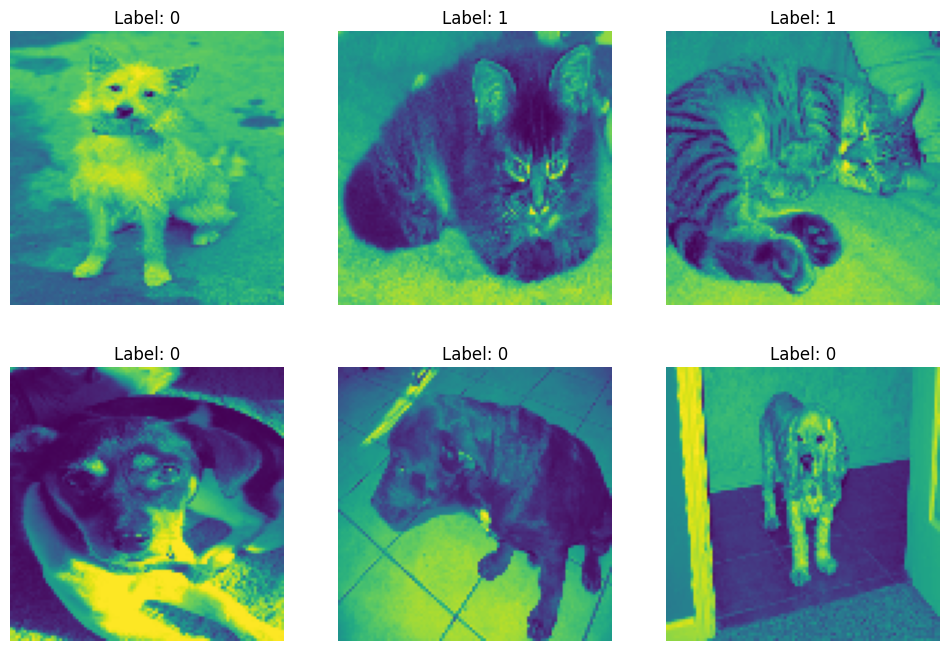

In [10]:
#View first six images
plt.figure(figsize=(12,8))

for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(image_array[i])
  plt.title(f'Label: {target[i]}')
  plt.axis('off')

plt.show()

Look at the response values in y for those images.

Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.

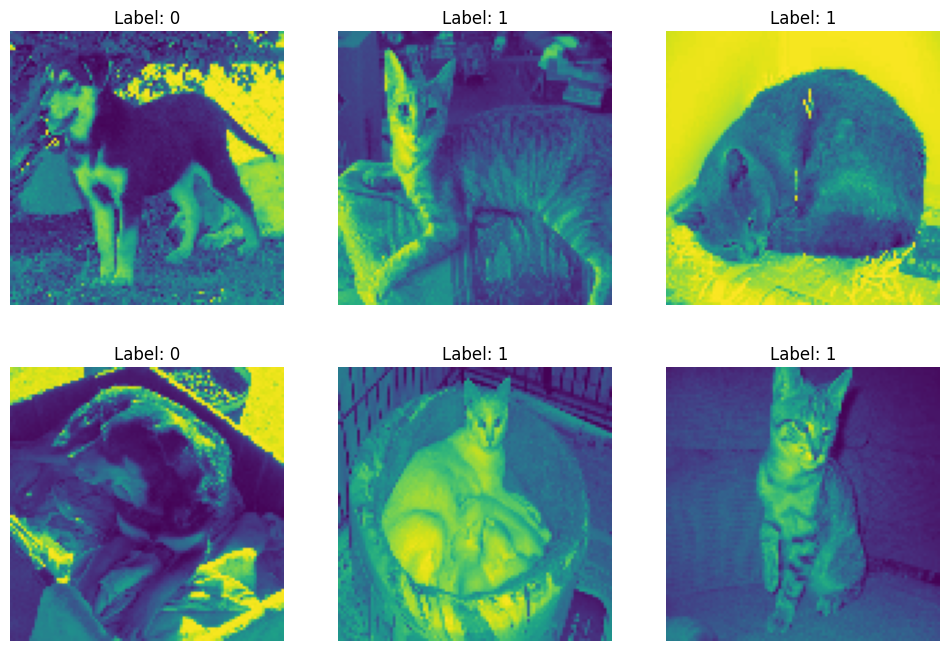

In [11]:
#Display random images
indices = np.random.choice(len(image_array), 6, replace=False)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):
  plt.subplot(2,3,i+1)
  plt.imshow(image_array[idx])
  plt.title(f'Label: {target[idx]}')
  plt.axis('off')

plt.show()

## Data Processing



Split X and y into training and testing sets.





In [12]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    image_array,
    target,
    test_size=0.20,
    random_state=42
)

Build a convolutional neural network with the following:
 * Sequential layers
 *  At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
 * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).

In [13]:
#Build CNN
#Sequential layers
model = Sequential()

In [14]:
#First Convolution Layer
model.add(Input(shape=X_train.shape[1:]))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

In [15]:
#Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.



In [16]:
#Flatten
model.add(Flatten())

In [17]:
#Hidden layer
model.add(Dense(64, activation='relu'))

In [18]:
#Output layer
model.add(Dense(1, activation='sigmoid'))

In [19]:
#View the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,481 (8.41 MB)

 Trainable params: 2,204,481 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

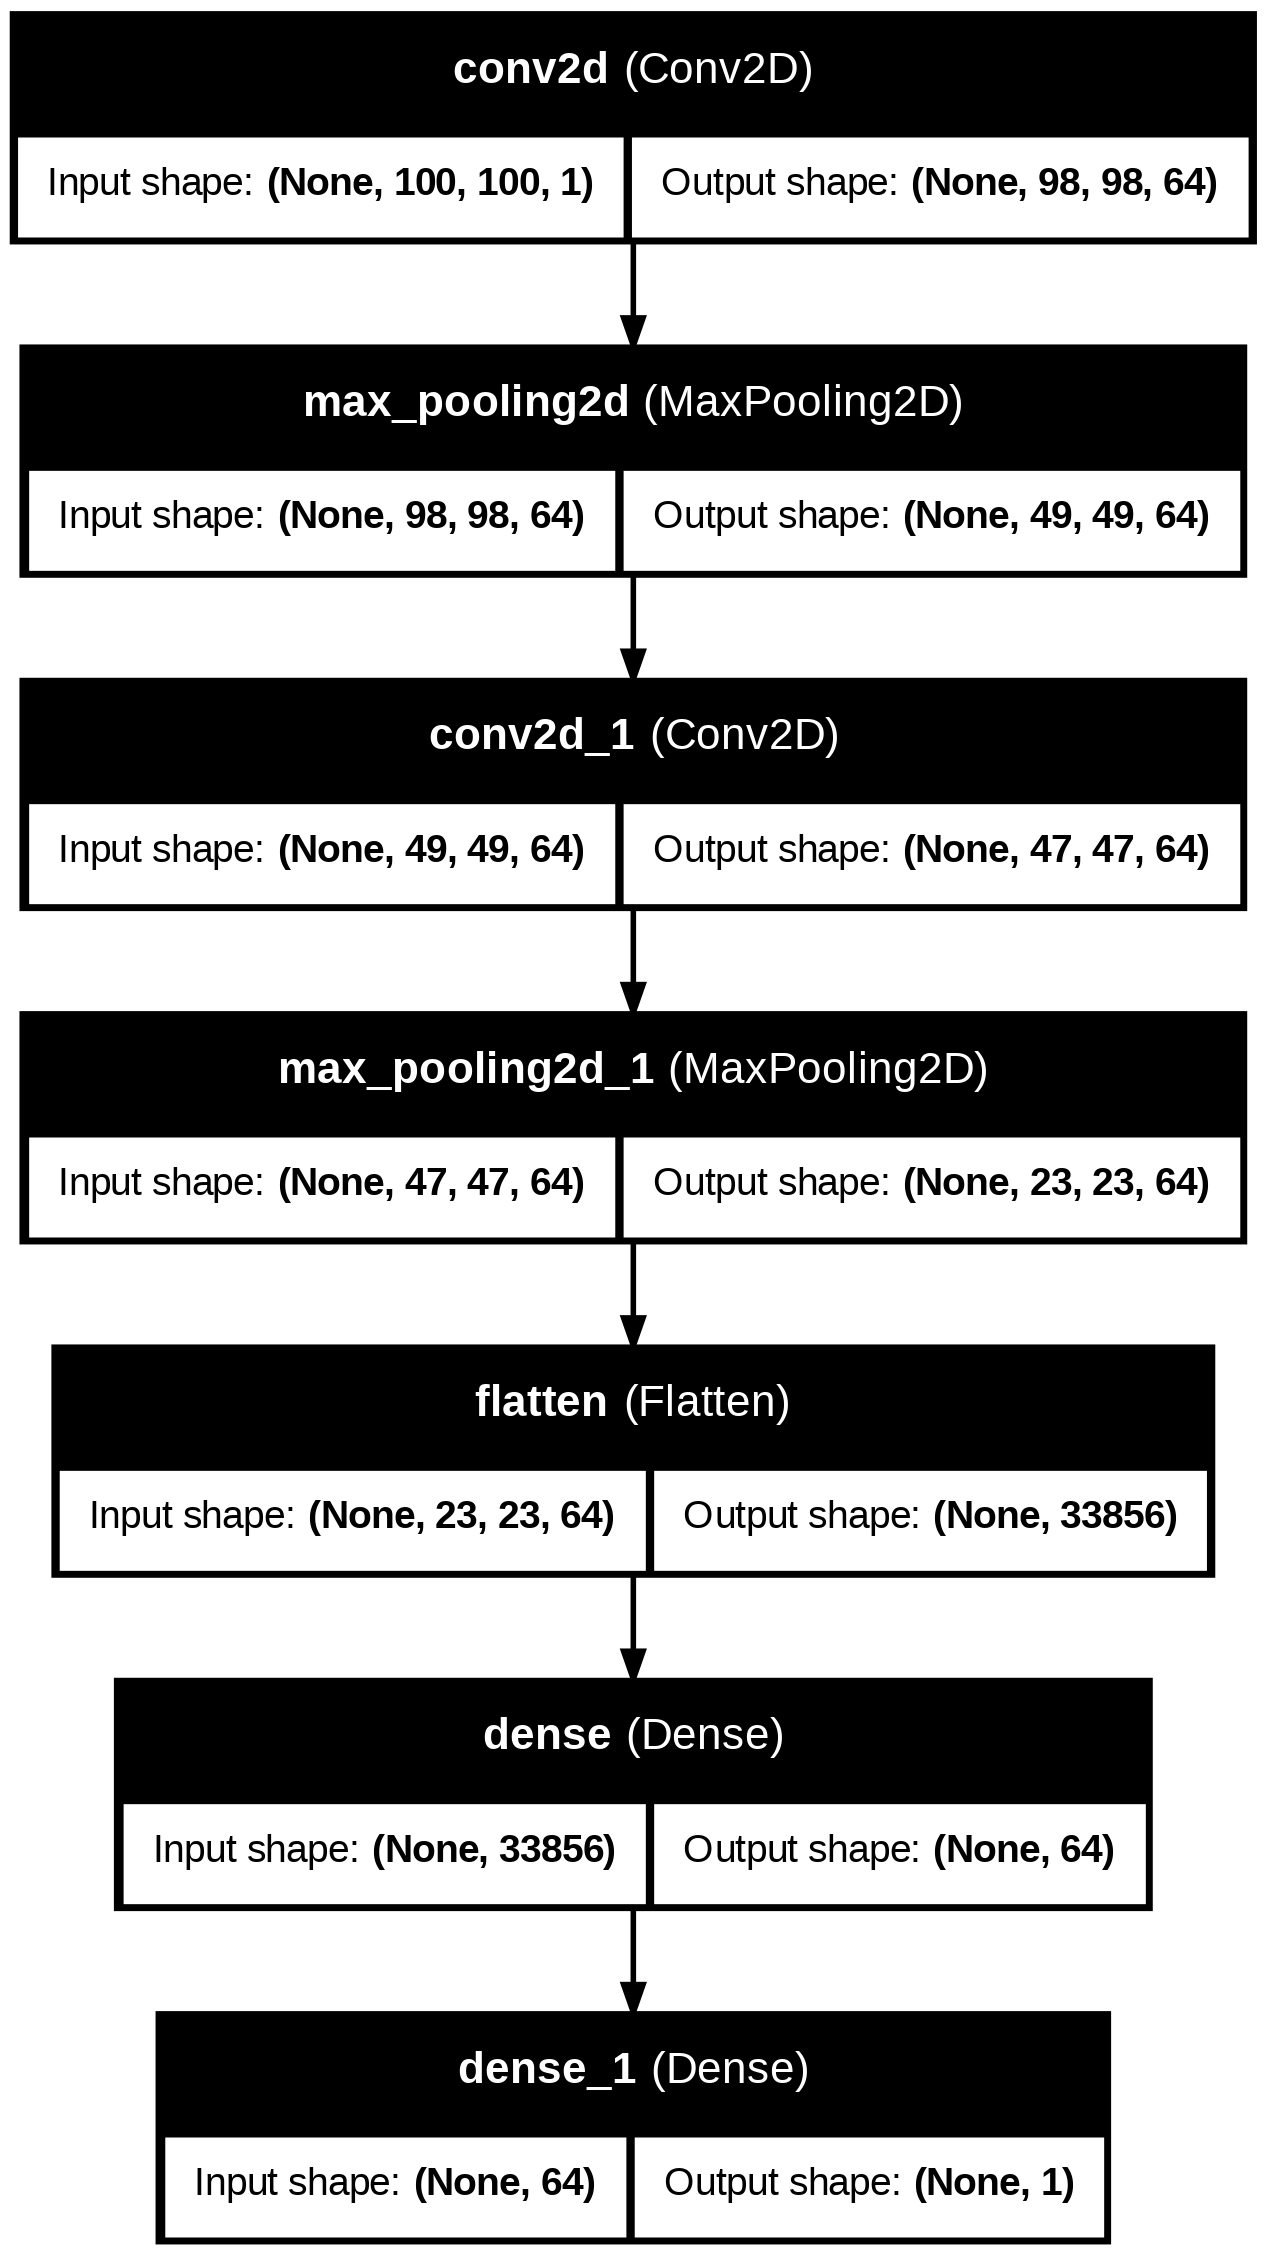

In [20]:
#Optional Architecture Diagram
plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.



###**Compile**

Since this is a **binary classification** problem:

* Optimizer → Adam
* Loss → Binary Crossentropy
* Metric → Accuracy

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Fit your model using the training set.



In [22]:
#Train
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 752ms/step - accuracy: 0.4611 - loss: 0.7716 - val_accuracy: 0.5250 - val_loss: 0.6931
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 736ms/step - accuracy: 0.5444 - loss: 0.6924 - val_accuracy: 0.5250 - val_loss: 0.6919
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 617ms/step - accuracy: 0.5556 - loss: 0.6930 - val_accuracy: 0.4500 - val_loss: 0.6905
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 606ms/step - accuracy: 0.6778 - loss: 0.6626 - val_accuracy: 0.5000 - val_loss: 0.7028
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 725ms/step - accuracy: 0.6667 - loss: 0.6103 - val_accuracy: 0.5250 - val_loss: 0.7280
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 718ms/step - accuracy: 0.7750 - loss: 0.5419 - val_accuracy: 0.4750 - val_loss: 0.7770
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 619ms/step - accuracy: 0.7778 - loss: 0.4515 - val_accuracy: 0.6500 - val_loss: 0.6783
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 606ms/step - accuracy: 0.9111 - loss: 0.3656 - val_accurac

Evaluate your model using the testing set.



In [23]:
#Evaluate
loss, accuracy = model.evaluate(X_test, y_test)

print('Loss:', loss)
print('Accuracy:', accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.6000 - loss: 0.9267
Loss: 0.9267284870147705
Accuracy: 0.6000000238418579


Plot the distribution of probabilities for the testing set.



In [24]:
#Predict probabilities
probabilities = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step


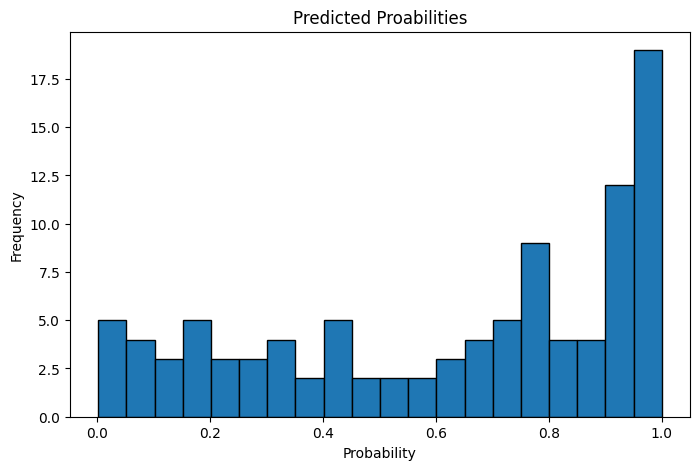

In [25]:
#Plot probability distribution
plt.figure(figsize=(8,5))

plt.hist(probabilities, bins=20, edgecolor='black')

plt.title('Predicted Proabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.show()

Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )



In [26]:
#Create function to prepare new image
def prepare_image(filepath):

  IMG_SIZE = 100

  img = image.load_img(
      filepath,
      target_size=(IMG_SIZE, IMG_SIZE),
      color_mode='grayscale'
  )

  img = image.img_to_array(img)
  img = img /255.0

  img = np.reshape(
      img,
      (1, IMG_SIZE, IMG_SIZE, 1)
  )

  return img

Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.



In [27]:
#Download test image
# image_path = tf.keras.utils.get_file(
tf.keras.utils.get_file(
    'dog.jpg',
    image_url
)

60603/60603 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


'/root/.keras/datasets/dog.jpg'

In [28]:
import os

os.listdir()

['.config', 'model.png', 'sample_data']

In [29]:
#Test shape before predicting
test_image = prepare_image('/root/.keras/datasets/dog.jpg')

print(test_image.shape)

(1, 100, 100, 1)


In [30]:
#Predict new image
prediction = model.predict(test_image)

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.12563321]], dtype=float32)

Use the neural network you created to predict whether the image is a dog or a cat.

In [31]:
#Display prediction
if prediction [0][0] > 0.5:
  print('Dog')
else:
  print('Cat')

Cat


## Communication of Results



Communicate the results of your analysis.



- CNN built to classify dog/cat images
- Images were normalized
- Split into training and test sets
- Used to train CNN with:
  - Convolutional layers
  - Max pooling
  - Sigmoid output layer

- Model trained using Adam optimization and binary cross-entrophy loss
- Accuracy evaluated on test set
- Model successfully classified new image (dog.jpg)
  - Demonstrated deep learning ability to recognize image patterns

## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.